# Autoencoders with Keras: Learning by Building

This notebook explains how autoencoders work and how to build one step by step using Keras.

The focus here is not just to run code, but to understand the structure and logic of the model.

In this notebook, we will:

- define what an autoencoder is
- understand the encoder, bottleneck, and decoder
- load and preprocess image data
- build a simple dense autoencoder in Keras
- train the model to reconstruct inputs
- compare original and reconstructed images
- extract the latent representation
- connect the method to practical real-world use cases

The dataset used is MNIST, a collection of handwritten digit images. It is simple enough for learning, but still useful for understanding the core ideas behind autoencoders.

This notebook is intentionally structured for learning. The explanations are written out clearly, and the code is meant to be typed manually so that the Keras workflow becomes more familiar through practice.


## 1. What is an autoencoder?

An autoencoder is a neural network that learns to reproduce its input.

It has two main parts:

- **Encoder**: compresses the input into a smaller representation
- **Decoder**: reconstructs the original input from that compressed representation

The compressed representation in the middle is called the **latent representation** or **latent vector**.

So the general flow looks like this:

`input -> encoder -> latent vector -> decoder -> reconstruction`

The important idea is that the network is forced to pass information through a bottleneck. If that bottleneck is smaller than the original input, the model cannot simply memorize every raw detail. It must learn the most useful structure of the data.

For image data, this can help the model learn shapes, patterns, and important visual structure in a compressed form.


## 2. Why are autoencoders useful?

Autoencoders are useful because they learn compressed internal representations of data without needing labels.

That makes them relevant in several real-world situations:

### Compression
The encoder can reduce a large input into a smaller latent representation.

### Denoising
An autoencoder can be trained to reconstruct clean data from noisy input.

### Anomaly detection
If the model is trained on normal examples, unusual examples often produce a higher reconstruction error.

### Feature extraction
The encoder learns useful features that can later be reused for clustering, classification, or visualization.

### Self-supervised learning
The target comes from the input itself, so no manual labels are needed for the reconstruction task.


## 3. Import the libraries

We start by importing the core libraries.

- `numpy` for numerical work
- `matplotlib` for visualization
- `keras` and `layers` for building the model
- `Model` for creating reusable encoder and autoencoder models
- `TSNE` for visualizing the latent space in 2D later

This is a good habit in deep learning notebooks: keep imports clean and grouped by purpose.


In [2]:
from os import name

import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers, Model

from sklearn.manifold import TSNE

## 4. Load the MNIST dataset

MNIST contains grayscale images of handwritten digits from 0 to 9.

Each image has shape `28 x 28`, and each pixel value ranges from `0` to `255`.

For an autoencoder, the labels are not needed during training because the target is the input itself. Still, we keep the labels because they are useful for inspection and for latent-space visualization later.


In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

 (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


## 5. Inspect a few example images

Before building a model, look at the data.

This is not optional if you want to become strong. Many people skip inspection and go straight into model training. That is lazy and it leads to shallow understanding.

Here, we display a few training examples with their labels.


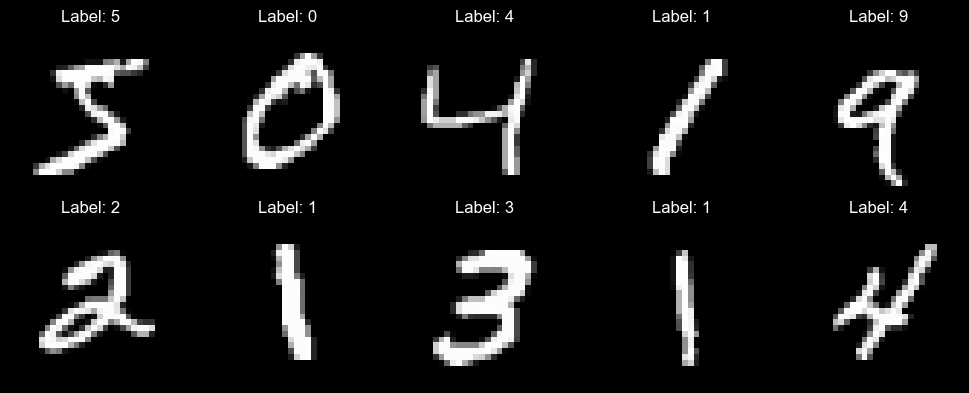

In [4]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 6. Preprocess the images

We do two things here:

### Normalize pixel values
We divide by `255.0` so pixel values move from `[0, 255]` into `[0, 1]`.

### Flatten each image
Because this first model uses `Dense` layers, each `28 x 28` image must be reshaped into a vector of size `784`.

This gives the model inputs in the form it expects.

Later, when you work with convolutional autoencoders, you will keep the image in its 2D structure.


In [5]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train_flat = x_train.reshape((len(x_train), 28 * 28))
x_test_flat = x_test.reshape((len(x_test), 28 * 28))

print("Flattened training shape:", x_train_flat.shape)
print("Flattened test shape:", x_test_flat.shape)

Flattened training shape: (60000, 784)
Flattened test shape: (10000, 784)


## 7. Define the autoencoder architecture

We now build a simple dense autoencoder.

The architecture will be:

- input layer: 784 units
- encoder hidden layer: 128 units
- latent bottleneck layer: 32 units
- decoder hidden layer: 128 units
- output layer: 784 units

### Why a bottleneck?
The bottleneck forces compression. The model must learn how to keep the most useful information in fewer dimensions.

### Why use ReLU?
ReLU helps the network learn nonlinear structure.

### Why sigmoid at the output?
Because the output needs to reconstruct normalized pixel values in the range `[0, 1]`.

We use the Keras Functional API because it makes it easier to later separate the encoder from the full model.


In [6]:
input_dim = 28 * 28
encoding_dim = 32

inputs = keras.Input(shape=(input_dim,),name="input_image")

x = layers.Dense(128, activation="relu", name="encoder_hidden")(inputs)
latent = layers.Dense(encoding_dim, activation="relu", name="latent_vector")(x)

x = layers.Dense(128, activation="relu", name="decoder_hidden")(latent)
outputs = layers.Dense(input_dim, activation="sigmoid", name="reconstructed_image")(x)

autoencoder = Model(inputs, outputs, name="dense_autoencoder")

autoencoder.summary()

 Non-trainable params: 0 (0.00 B)

## 8. Compile the model

Now we define how the model should train.

### Optimizer
We use `Adam`, which is a strong default optimizer for many deep learning tasks.

### Loss function
We use `binary_crossentropy`, which is often used when inputs are normalized into `[0, 1]` and the output uses a sigmoid activation.

You should know that `mse` is also common for reconstruction tasks. Later, you should compare both and observe what changes.


In [7]:
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")

## 9. Train the autoencoder

This is the core training idea:

- input = original image
- target = same original image

That means the network learns by trying to reconstruct the input.

We also include validation data to observe how well the model performs on unseen images.


In [8]:
history = autoencoder.fit(
    x_train_flat,
    x_train_flat,
    epochs=15,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_flat, x_test_flat)
)

235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0938 - val_loss: 0.0927


## 10. Plot training and validation loss

The loss values help us see whether the model is learning.

A decreasing validation loss is a good sign that the model is learning useful structure instead of failing on unseen data.

Never just train and move on. Always inspect learning behavior.


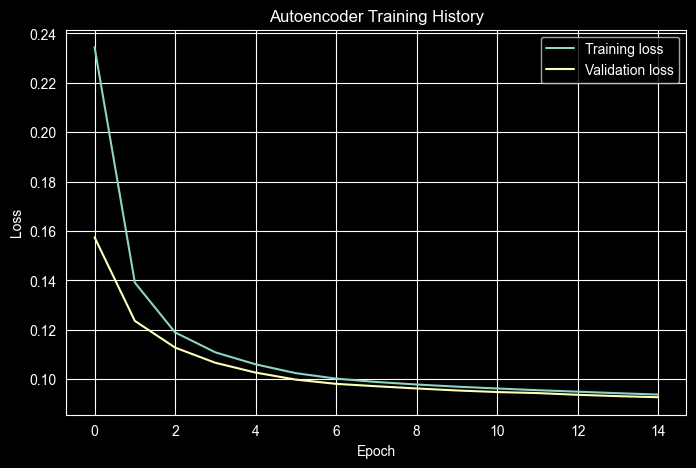

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Autoencoder Training History")
plt.legend()
plt.show()

## 11. Reconstruct images from the test set

Once training is done, we pass test images through the autoencoder.

The output is not a class label. It is a reconstructed version of the original input.

This matters because autoencoders are not classifiers. Their job is reconstruction.


In [10]:
reconstructed_images = autoencoder.predict(x_test_flat)
print("Reconstructed shape:", reconstructed_images.shape)

 (10000, 784)


## 12. Compare original and reconstructed images

This is one of the most important visual checks.

We will show:

- the original test image
- the reconstructed version produced by the autoencoder

Because the model compresses each image into only 32 numbers, the reconstruction will not be perfect. That is expected. What matters is whether the main digit structure is preserved.


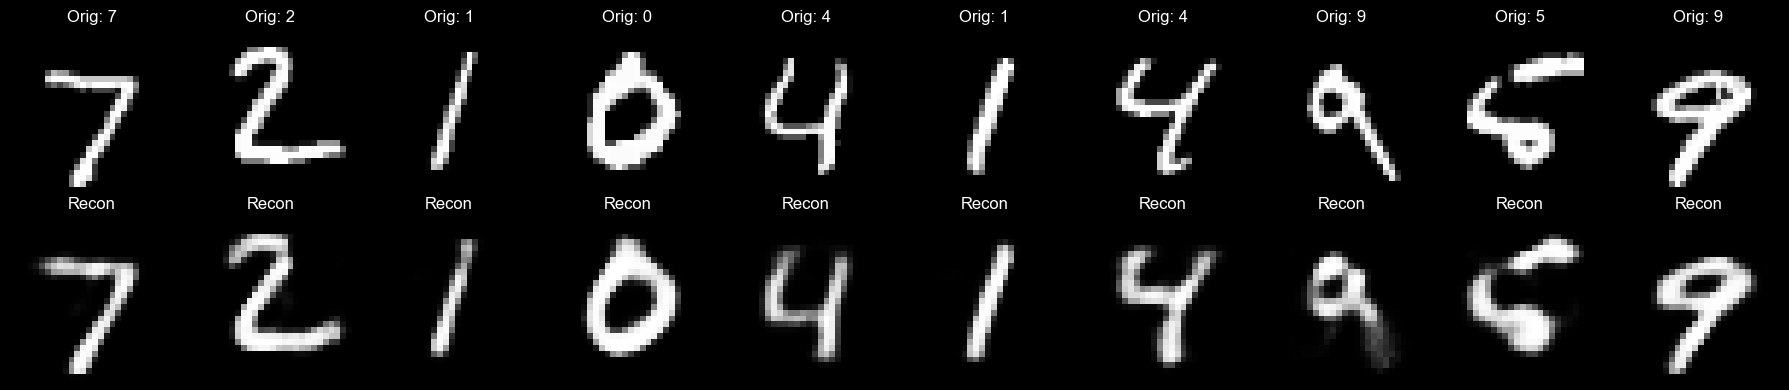

In [11]:
n = 10
plt.figure(figsize=(18, 4))

for i in range(n):
    plt.subplot(2, n, i + 1)
    plt.imshow(x_test_flat[i].reshape(28, 28), cmap="gray")
    plt.title(f"Orig: {y_test[i]}")
    plt.axis("off")

    plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed_images[i].reshape(28, 28), cmap="gray")
    plt.title("Recon")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 13. Build a separate encoder model

In practice, the encoder is often the most valuable part of the autoencoder because it creates the learned latent representation.

That latent representation can later be used for:

- clustering
- visualization
- classification
- anomaly detection
- similarity search

Because we used the Functional API, extracting the encoder is straightforward.


In [12]:
encoder = Model(inputs, latent, name="encoder")
encoder.summary()

 Non-trainable params: 0 (0.00 B)

## 14. Generate latent vectors

The encoder transforms each input image from a 784-dimensional vector into a 32-dimensional latent vector.

That latent vector is the compressed learned summary of the image.


In [13]:
latent_vectors = encoder.predict(x_test_flat)
print("Latent vectors shape:", latent_vectors.shape)

Latent vectors shape: (10000, 32)


## 15. Visualize the latent space with t-SNE

The latent vectors have 32 dimensions, which is too many to view directly.

So we use t-SNE to project them into 2 dimensions for visualization.

This does not change the autoencoder itself. It is only a way to inspect whether similar digits end up near each other in the learned feature space.


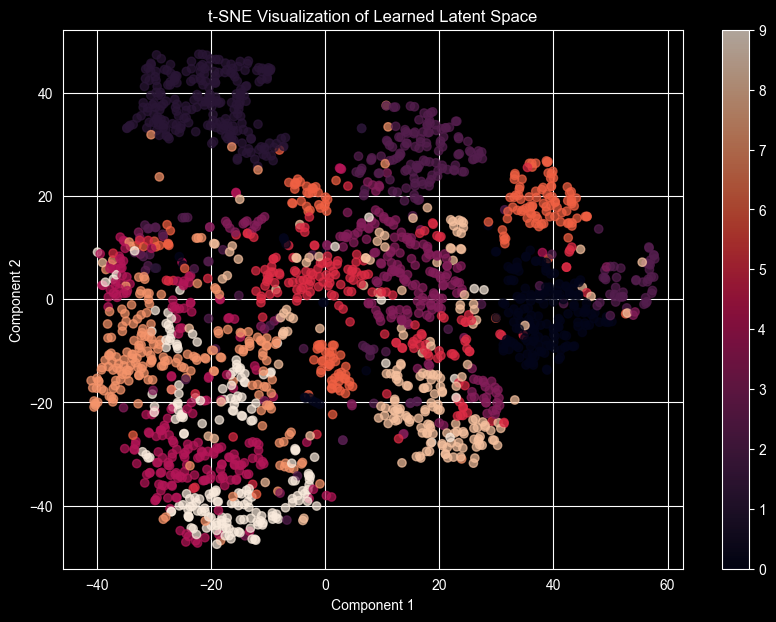

In [14]:
subset_size = 2000
latent_subset = latent_vectors[:subset_size]
labels_subset = y_test[:subset_size]

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
latent_2d = tsne.fit_transform(latent_subset)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=labels_subset, alpha=0.7)
plt.colorbar(scatter)
plt.title("t-SNE Visualization of Learned Latent Space")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

## 16. Compute reconstruction error

A practical next step is to measure reconstruction error per sample.

A common simple choice is mean squared error between the original image and its reconstruction.

This becomes especially important in anomaly detection. If a model is trained only on normal data, unusual inputs are often reconstructed poorly and produce larger errors.


In [15]:
reconstruction_error = np.mean((x_test_flat - reconstructed_images) ** 2, axis=1)

print("Mean reconstruction error:", reconstruction_error.mean())
print("Min reconstruction error:", reconstruction_error.min())
print("Max reconstruction error:", reconstruction_error.max())

Mean reconstruction error: 0.0101440055
Min reconstruction error: 0.0005862629
Max reconstruction error: 0.045513794


## 17. Plot the distribution of reconstruction error

This helps us see how reconstruction quality varies across samples.

In anomaly detection settings, a threshold can be chosen from this kind of distribution to flag suspicious samples.

That threshold should never be picked blindly. It should be validated with real data and real costs in mind.


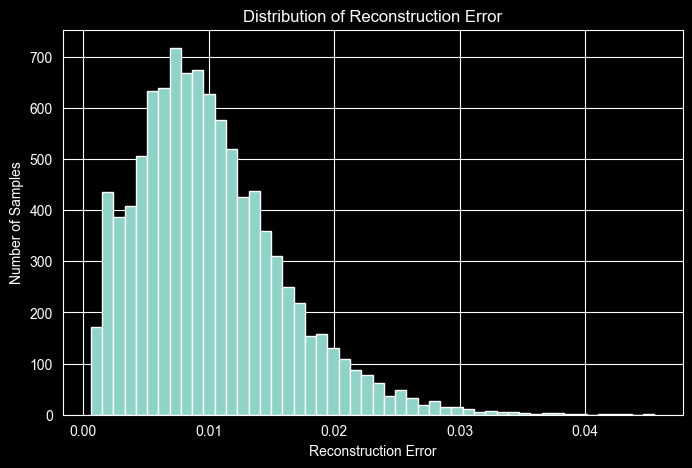

In [16]:
plt.figure(figsize=(8, 5))
plt.hist(reconstruction_error, bins=50)
plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Samples")
plt.title("Distribution of Reconstruction Error")
plt.show()

## 18. Show best and worst reconstructions

Average metrics are not enough. You should always inspect examples.

Here we find:

- the sample with the lowest reconstruction error
- the sample with the highest reconstruction error

This makes model behavior more concrete and helps build intuition.


In [19]:
best_idx = np.argmin(reconstruction_error)
worst_idx = np.argmax(reconstruction_error)

plt.figure(figsize=(8, 4))

plt.subplot(2, 2, 1)
plt.imshow(x_test_flat[best_idx].reshape(28, 28), cmap="gray")
plt.title("Best Original")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(reconstructed_images[best_idx].reshape(28, 28), cmap="gray")
plt.title("Best Reconstruction")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(x_test_flat[worst_idx].reshape(28, 28), cmap="gray")
plt.title("Worst Original")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(reconstructed_images[worst_idx].reshape(28, 28), cmap="gray")
plt.title("Worst Reconstruction")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Best reconstruction error:", reconstruction_error[best_idx])
print("Worst reconstruction error:", reconstruction_error[worst_idx])

Best reconstruction error: 0.0005862629
Worst reconstruction error: 0.045513794


## Limitations of this simple dense autoencoder

This notebook is strong for learning, but it is still a basic model.

Its limits include:

- the image is flattened, so spatial structure is not used well
- dense layers are weaker than convolutional layers for image tasks
- the latent space is learned but not explicitly regularized
- good reconstruction does not automatically mean good semantic understanding

That is why a natural next step is to build a convolutional autoencoder.
